## Von der Lexikonabfrage zur Korpusannotation: Arbeiten mit LexFCS in Python

Paul möchte Personenbezeichnungen im Deutschen untersuchen – aber wie kommt er schnell an saubere, für seine Forschungsfrage relevante Daten?  
Eine Kollegin macht ihn auf die LexFCS aufmerksam. Dort seien die verschiedensten lexikalischen Ressourcen, u. a. umfangreiche Wörterbücher und Korpora für das Deutsche, aggregiert worden.  
So muss Paul sich keine Sorge machen, dass er für jede Ressource neuen Code schreiben muss: Das Rückgabeformat ist über alle Ressourcen hinweg standardisiert.  
Für Paul klingt diese Lösung vielversprechend: So viele Ressourcen in einem Schlag konsultieren zu können wird ihm nicht nur viel Zeit ersparen, sondern auch eine höhere Abdeckung ermöglichen.


In [25]:
# Import der notwendigen Python-Libraries
import requests
import pandas as pd
import re
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from lxml import etree
import time

In [26]:
# IDS Endpunkt
base_url_ids = 'https://www.owid.de/api/fcs/'

# LXML Parser
parser = etree.XMLParser(recover=True)

# Dictionary zum Mapping der XML Namespaces beim Parsing
ns = {
    'sruResponse': 'http://docs.oasis-open.org/ns/search-ws/sruResponse',
    'fcs': 'http://clarin.eu/fcs/resource',
    'hits': 'http://clarin.eu/fcs/dataview/hits'
}

## Basics zur API und zur Output-Struktur


Eine gute Einleitung zur _requests_ Library in Python findet sich [hier](https://realpython.com/python-requests/).

Zunächst möchte Paul verstehen, wie er mit dem Endpunkt interagieren kann und was dieser zurückgibt. Die Operation _explain_ liefert hierfür wichtige Erkenntnisse über die Kapazitäten eines Endpunkts.


In [27]:
def make_explain_request(url):
    explain_response = requests.get(url, params={
        'operation': 'explain',
        'x-fcs-endpoint-description': 'true'
        })

    try:
        explain_response.raise_for_status()
    except requests.exception.HTTPError as http_err:
        print(f'HTTP error occurred: {http_err}')
    else:
        print('API call was a success! \n')

    explain_response_content = explain_response.content
    explain_response_root = etree.fromstring(explain_response_content, parser=parser)
    explain_response_tree = etree.ElementTree(explain_response_root)

    explain_response_tree.write(
    'explain_response.xml',
    encoding='utf-8',
    pretty_print=True,
    xml_declaration=True)    
    global root
    root = explain_response_tree.getroot()

make_explain_request(base_url_ids)
    

API call was a success! 



![title](pics/expresponse.png)

Paul schaut sich drei wichtige Bereiche im Output der Explain-Request an.

- **Capabilities**  
  Im Bereich Capabilities finden sich die möglichen Suchmodi für den jeweiligen Endpunkt. In diesem Fall heißt es, dass sowohl die Basic als auch die Advanced (lexikalische) Suche unterstützt werden


In [28]:
capabilities = root.xpath('//*[local-name()="Capability"]/text()')
capabilities

['http://clarin.eu/fcs/capability/basic-search',
 'http://clarin.eu/fcs/capability/lex-search']

- **Resources**  
  Unter Resources werden sämtliche Ressourcen aufgelistet, die im Endpunkt enthalten sind. An diesem Beispiel wird erkennbar, dass dieser Endpunkt die Abfrage des Wörterbuchs _elexiko_ ermöglicht. Dabei können die lexikalischen Felder im Element _AvailableLexFields_ genutzt werden, um Abfragen zu formulieren


In [29]:
resources = root.xpath('//*[local-name()="Resource"]/*[local-name()="Title" and @xml:lang="de"]/text()')
resources

['elexiko - Online-Wörterbuch zur deutschen Gegenwartssprache',
 'Neologismenwörterbuch',
 'Sprichwörterbuch',
 'Paronyme – Dynamisch im Kontrast',
 'Kommunikationsverben',
 'Deutsches Fremdwörterbuch',
 'Demokratiediskurs 1918–1925',
 'Schulddiskurs 1945–55',
 'Protestdiskurs 1967/68',
 'Schlüsselwörter der Wendezeit',
 'Kleines Wörterbuch der Verlaufsformen im Deutschen']

- **SupportedLexFields**  
  Hier werden die Felder aufgeführt, die vom Endpunkt allgemein unterstützt werden, also sämtliche mögliche Features, die ihm ressourcenübergreifend bekannt sind


In [30]:
supported_lex_fields = root.xpath('//*[local-name()="SupportedLexField"]/text()')
supported_lex_fields

['lemma',
 'entryId',
 'source',
 'senseRef',
 'lang',
 'pos',
 'definition',
 'segmentation',
 'gender',
 'number',
 'citation',
 'link',
 'synonym',
 'antonym',
 'hyponym',
 'hypernym']

## Beispiel für advanced search


In [31]:
# Ein Beispiel für eine Advanced Search
response = requests.get(
    base_url_ids,
    params={
        'operation': 'searchRetrieve',
        'queryType': 'lex',
        'query': 'lemma = "Berg"',
        'maximumRecords': 1000,
    },
)
response.raise_for_status()

response_content = response.content
response_root = etree.fromstring(response_content, parser=parser)
response_tree = etree.ElementTree(response_root)

# Schreibe die Response in ein XML-Dokument
response_tree.write(
    'advanced_search_output.xml',
    encoding='utf-8',
    pretty_print=True,
    xml_declaration=True
)

![title](pics/advanced.png)

Hier ist ein Ausschnitt einer API Response bei erfolgreicher Abfrage. In diesem Fall handelt es sich um einen Eintrag, der in der Ressource _elexiko_ gefunden wurde.  
Bei der Advanced Search sind die Ergebnisse pro gematchtem Artikel in zwei verschiedenen Formaten gegliedert:

1. einmal in kondensierter Form in der _hits Data View_ (oben auf der linken Seite)
2. und einmal in der _lex Data View_. Dort sind ähnliche Informationen wie in der anderen Data View enthalten, allerdings mit Links (z. B. zu Tagsets oder zum Artikel selbst) angereichert und nach jedem Feld aufgeschlüsselt (unten rechts)


In [32]:
root = response_tree.getroot()
nodes = root.xpath('//*[local-name()="Result"]')
outputs = [
  f'{node.xpath("string(.//hits:Hit[@kind=\'lex-lemma\'])", namespaces=ns).strip()} '
  f'({node.xpath("string(.//hits:Hit[@kind=\'lex-pos\'])", namespaces=ns).strip()}) '
  f'[{node.xpath("string(.//hits:Hit[@kind=\'lex-gender\'])", namespaces=ns).strip()}]: '
  f'{node.xpath("string(.//hits:Hit[@kind=\'lex-def\'])", namespaces=ns).strip()}'
  for node in nodes
]

outputs

['Berg (nomen, NOUN) [maskulinum, Masc]: Mit Berg bezeichnet man eine große, massive Erhebung aus Erde und Gestein im Gelände.',
 'Berg (nomen, NOUN) [maskulinum, Masc]: Mit Berg bezeichnet man eine größere Ansammlung von Material oder Gegenständen. In übertragener Verwendung bezeichnet man mit Bergeine Vielzahl von Sachverhalten (z. B. Aufgaben, Probleme).',
 'Berg (nomen, NOUN) [maskulinum, Masc]: Mit Berge bezeichnet man die Gesamtheit mehrerer hoher Erhebungen, die zusammen ein Gebirge ergeben.',
 'Wenn der Berg nicht zum Propheten kommt, muss der Prophet zum Berg kommen. () []: Sagt man, wenn jemand in Bezug auf einen anderen nicht aktiv wird und der andere deshalb selbst die Initiative ergreift.']

## Boilerplate Code – grundlegend und wiederverwendbar

Da der Output der LexFCS nach einem definierten Schema geliefert wird, kann Paul sich schnell einige Funktionen zurechtlegen, mit denen er gleichermaßen Korpora und Wörterbücher durch die API konsultieren kann.  
Der Code ist relativ einfach zu schreiben und zu verstehen, und der Aufwand ist einmalig. In Zukunft wird er dann nur die gewünschte Query einfügen und schon kann es mit der nächsten Abfrage losgehen. Dank der LexFCS hat er Zugriff nicht nur auf Daten, sondern strukturierte, kombinierbare Suchdimensionen.


In [33]:
# Mache eine API Request (Advanced Search)
def api_query_advanced(base_url, query, start_record=1, max_records=1000, **additional_params):
    base_params={
        'operation': 'searchRetrieve',
        'query': query,
        'maximumRecords': max_records,
        'startRecord': start_record,
    }
    
    base_params.update(additional_params)

    response = requests.get(base_url, params=base_params)
    response.raise_for_status()
    return response.content

# Parse den XML-Output
def parse_xml(xml_bytes):
    return etree.fromstring(xml_bytes, parser=parser)

# Extrahiere die Gesamtzahl der Matches (im Element 'numberOfRecords' des XML-Dokuments)
def get_num_records(root):
    el = root.find('.//sruResponse:numberOfRecords', namespaces=ns)
    # print(f'Total number of records: {int((el.text))}')
    return int(el.text) if el is not None else 0

# Extrahiere Matches (Wörterbücher)
def extract_lemmas(root):
    lemmas = set()

    records = root.findall('.//sruResponse:record', namespaces=ns)

    for record in records:
        hits = record.findall('.//hits:Hit', namespaces=ns)
        for hit in hits:
            if hit.get('kind') == 'lex-lemma':
                if hit.text:
                    lemmas.add(hit.text)

    return lemmas

# Extrahiere Matches (Korpora)
def extract_sentences(root):
    sentences = set()

    records = root.findall('.//sruResponse:record', namespaces=ns)

    for record in records:
        results = record.findall('.//hits:Result', namespaces=ns)
        for res in results:
            sentences.add(''.join(res.itertext()))

    return sentences

# Vollständige Pipeline zur Abfrage und zum Parsing
def run_query(base_url, query, resource_type):
    
    if resource_type == 'dictionary':
        xml = api_query_advanced(
            base_url,
            query,
            queryType='lex'
        )

    elif resource_type == 'corpus':
        xml = api_query_advanced(
            base_url,
            query,
            queryType='fcs',
            **{
                'x-fcs-dataview': 'hits'
            }
        )

    else:
        raise ValueError("Unknown resource type. Select 'dictionary' or 'corpus'.")

    root = parse_xml(xml)
    num_records = get_num_records(root)

    if resource_type == 'dictionary':
        data = extract_lemmas(root)
    else:
        data = extract_sentences(root)

    return list(data), num_records

# Speichere Matches als Excel oder CSV
def save_df(data, output_name, view):
    
    # Wenn bereits DataFrame -> direkt speichern
    if isinstance(data, pd.DataFrame):
        df = data
    
    # Wenn dictionary -> jede Query eine Spalte
    elif isinstance(data, dict):
        df = pd.DataFrame(dict((k, pd.Series(v)) for k, v in data.items()))
        df = df.fillna('')
    
    # Wenn corpus -> Lemma + Satz mit Lemma
    elif isinstance(data, list):
        df = pd.DataFrame(data)
    
    else:
        raise ValueError("Unsupported data format")

    if view == 'xlsx':
        df.to_excel(output_name, index=False)
    elif view == 'csv':
        df.to_csv(output_name, index=False)

## Abfragemöglichkeiten

Paul überlegt, wie er am besten an movierten Feminina herankommt. Dafür probiert er verschiedene Abfragefelder der LexFCS aus. Dabei denkt er nach dem "Drill-Down-Prinzip": Das heißt, er fängt an mit einer eher allgemeinen Abfrage und versucht diese dann Schritt für Schritt einzuschränken.

**1. lemma = \*in**  
Es handelt sich um eine rein formale Suche auf Lemma-Ebene. Hier kann man mit einem hohen Recall rechnen, da alle Lemmata gematched werden, die die Sequenz _-in_ enthalten. Das Lemma-Feld ist in jedem Fall vorausgesetzt, weshalb hierfür die meisten Treffer zu erwarten sind. Diese Suche ist zwar für die Abfrage movierter Personenbezeichnungen passend, allerdings schließt sie im Output auch Lemmata mit ein, die keine Personenbezeichnungen sind (z. B. Verben wie _herabsinken_ oder Adjektive wie _gemein_).

**2. pos = NOUN AND lemma = \*in**  
Durch die Spezifizierung der Wortart im Feld _pos_ wird die Suche auf Nomen eingeschränkt.

**3. pos = NOUN AND lemma = \*in AND (definition = Person OR definition = Mensch OR definition = Frau)**  
Neben der formalen Ebene kann die Definition eines Lemmas ebenfalls Hinweise für eine Personenbezeichnung enthalten.

**4. pos = NOUN AND lemma = \*in AND (definition = Person OR definition = Mensch OR definition = Frau) AND gender = Fem**  
Gleiches gilt für das Genus eines Lemmas.

**5. segmentation = "|rin" OR segmentation = "|tin" OR segmentation = "|gin" OR segmentation = "|min" OR segmentation = "|sin" OR segmentation = "|chin" OR segmentation = "|fin" OR segmentation = "|phin"**  
Das Feld _segmentation_ ermöglicht eine alternative, im Vergleich zu _lemma_ (s. oben) etwas striktere formale Suche. Durch die Angabe der Silbenposition mittels Pipe-Zeichen (|) werden die o. g. unerwünschten Ergebnisse ausgeschlossen. Auch ist dieses Feld besonders nützlich, wenn in einem Wörterbuch inhaltliche Felder wie _definition_ oder grammatische Angaben wie _pos_ oder _gender_ nicht ausreichend ausgefüllt sind und man bei der Abfrage auf die formale Ebene angewiesen ist.


In [34]:
queries_movierung = {
    'lemma': 'lemma = *in',
    # 1. Formale Lemma-Suche (Welche Lemmata beinhalten die Sequenz '-in'?)
    
    'lemma_pos': 'pos = NOUN AND lemma = *in',
    # 2. Erweiterung um die Wortart "Nomen"

    'lemma_pos_definition': 'pos = NOUN AND lemma = *in AND (definition = Person OR definition = Mensch OR definition = Frau)',
    # 3. Erweiterung um die Definition (Person, Mensch, Frau)

    'lemma_pos_definition_gender': 'pos = NOUN AND lemma = *in AND (definition = Person OR definition = Mensch OR definition = Frau) AND gender = Fem',
    # 4. Erweiterung um das Genus
    
   'segmentation': 'segmentation = "|rin" OR segmentation = "|tin" OR segmentation = "|gin" OR segmentation = "|min" OR segmentation = "|sin" OR segmentation = "|chin" OR segmentation = "|fin" OR segmentation = "|phin"',
    # 5. Fokus auf Movierungsmöglichkeiten auf Grundlage der Silbentrennung (s. Nübling & Rosar, 2025)
}

In [35]:

# Für jede formulierte Abfrage wendet er jetzt die Abfrage-Pipeline an

results_movierung = {}
 
for label, query in queries_movierung.items():
    print(f'\n--- Running query: {label} ---')
    records, num_records = run_query(base_url_ids, query, resource_type='dictionary')
    results_movierung[label] = records

save_df(results=results_movierung, output_name='output_movierung.xlsx', view='xlsx')


--- Running query: lemma ---

--- Running query: lemma_pos ---

--- Running query: lemma_pos_definition ---

--- Running query: lemma_pos_definition_gender ---

--- Running query: segmentation ---


TypeError: save_df() got an unexpected keyword argument 'results'

## Visualisierung der Ergebnisse

- Wie viele Lemmata wurden pro Abfrage gematched?
- Wie ähnlich oder unterschiedlich sind die Matches je nach Query?

Paul analysiert dies anhand von Säulen- und Mengendiagrammen.


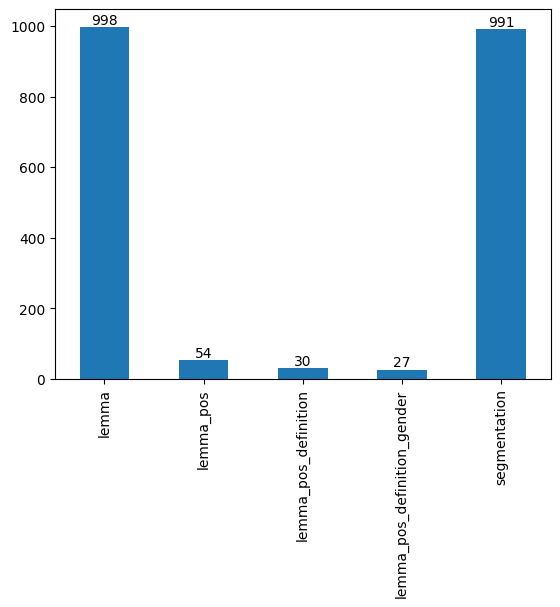

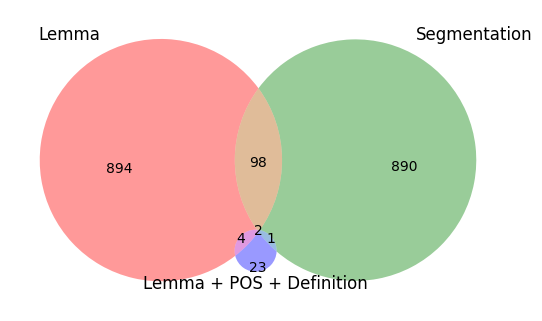

In [36]:
# Visualisiere die Anzahl der Matches pro Abfrage (Säulendiagramm)
def plot_bar(sizes, filename, save_plot=False):
    ax = pd.Series(sizes).plot(kind='bar')
    for i, v in enumerate(sizes.values()):
        ax.text(i, v, str(v), ha='center', va='bottom') 
    if save_plot:
        plt.savefig(filename, dpi=300, bbox_inches='tight')

# Visualisiere die Anzahl der gemeinsamen Matches unter den verschiedenen Abfragen (Mengendiagramm)
def plot_venn(sets, filename, save_plot=False):
    plt.figure()
    venn3(list(sets.values()), set_labels=sets.keys())
    if save_plot:
        plt.savefig(filename, dpi=300, bbox_inches='tight')

# Exportiere Types pro Abfrage
def export_sets(set1, set2, filename):
    df = pd.DataFrame({
    'union': pd.Series(list(set1 & set2)),
    'only_lemma_query': pd.Series(list(set1 - set2)),
    'only_segmentation_query': pd.Series(list(set2 - set1))
    })
    df.to_excel(filename, index=False)

# Vollständige Pipeline zur Visualisierung
def plot_stats(results):
    sizes = {k: len(v) for k, v in results.items()}

    venn_sets = {
        'Lemma': set(results['lemma']),
        'Segmentation': set(results['segmentation']),
        'Lemma + POS + Definition': set(results['lemma_pos_definition'])
    }

    set1, set2, set3 = venn_sets.values()

    plot_bar(sizes, filename='matches_per_query.png', save_plot=True)
    plot_venn(venn_sets, filename='venn_plot.png', save_plot=True)
    export_sets(set1, set2, filename='lemma_segmentation_comparison.xlsx')

    return set1, set2, set3

plot_stats(results_movierung);

## Ergebnissanalyse

Paul analysiert die Ergebnisse der verschiedenen Abfragen.

- Die Abfrage der Felder _lemma_ und _segmentation_ liefert die meisten (ca. 1000) Ergebnisse
- Durch die Kombination aus _lemma_ und _pos_ erhöht sich die Precision der Matches, allerdings sinkt der Recall drastisch (von mehreren Tausenden zu 50 Matches)
- Mit der Erweiterung um die _definition_ wird die Rückgabe noch präziser, allerdings werden nur 31 Matches gefunden mit einigen noch irrelevanten Lemmas (z. B. _Nein_, weil mindestens einer der im Query angegebenen Tokens für das Feld _definition_ gematched wurde)
- Die Spezifizierung des _gender_ erzeugt eine saubere Token-Liste. Die Gesamtzahl ist hierbei jedoch 28

Da für Pauls Forschungsfrage ein höherer Recall am wichtigsten ist, beschließt er, die Ergebnisse aus _lemma_ und _segmentation_ zusammenzufügen. Daraufhin führt er eine manuelle Überprüfung durch, um eventuelle False Positive zu entfernen.


## Erschließung neuer Suchmöglichkeiten – Maskulina derivieren

Paul versucht, aus der vorhandenen Token-Liste neue Suchtermini zu erzeugen. So kommt er auf die Idee, aus den movierten Feminina Stems herzuleiten, indem er die Endung _-in_ konsequent entfernt.


In [37]:
# Entferne die Endung -in bei jedem Token
def remove_feminine_suffix(df, col_lemma, col_segmentation, output_path, view):

    df = pd.read_excel(df)
    feminine_lemmas = list(df[col_lemma]) + list(df[col_segmentation])

    stemmed_lemmas = []

    for lemma in feminine_lemmas:
        if type(lemma) == str:
            lemma = re.sub(r'in$', '', lemma)
            stemmed_lemmas.append(lemma)
        else:
            continue
        
    df_output = pd.DataFrame({
        'stems': pd.Series(stemmed_lemmas)
    })
    
    if view == 'xlsx':
        df_output.to_excel(output_path, index=False)
    elif view == 'csv':
        df_output.to_csv(output_path, index=False)

    return set(feminine_lemmas), set(stemmed_lemmas)

feminine_lemmas, stemmed_lemmas = remove_feminine_suffix(df=r'lemma_segmentation_comparison.xlsx', col_lemma='only_lemma_query', col_segmentation='only_segmentation_query', view='xlsx', output_path=r'stemmed_lemmas.xlsx');

In [38]:
masculine_lemmas = set()

# Funktion zur Berücksichtigung der männlichen Form mit Vokalwechsel bei der Ableitung von der weiblichen Form (Ärztin -> Ärzt/Arzt -> Arzt), simuliert das Flag ignoreAccent in LexFCS
def generate_variants(term, umlauts):
    variants = set([term])

    for i, char in enumerate(term):
        if char in umlauts:
            new_term = term[:i] + umlauts[char] + term[i+1:]
            variants.add(new_term)

    return variants

masculine_lemmas = set()
test = []

umlauts = {'ä': 'a', 'ü': 'u', 'ö': 'o', 'Ä': 'A', 'Ü': 'U', 'Ö': 'O'}

for stem in stemmed_lemmas:
    variants = generate_variants(stem, umlauts)

    for variant in variants:
        query = f'lemma =/regexp "^{variant}[a-zA-Z]{{0,1}}$"'
        print(query)

        tokens = extract_lemmas(base_url=base_url_ids, query=query)

        for token in tokens:
            if token in feminine_lemmas:
                continue
            else:
                masculine_lemmas.add(token)

print(f'Total masculine lemmas found: {len(masculine_lemmas)}')

masculine_lemmas = list(masculine_lemmas)
feminine_lemmas = list(feminine_lemmas)

df_fem_masc = pd.DataFrame({
    'feminine_lemmas': pd.Series(feminine_lemmas),
    'masculine_lemmas': pd.Series(masculine_lemmas)})
df_fem_masc.to_excel('fem_masc_lemmas.xlsx')

lemma =/regexp "^[a-zA-Z]{0,1}$"


TypeError: extract_lemmas() got an unexpected keyword argument 'base_url'

## Korpusabfrage


Auf Grundlage der gefundenen Lemmata kann Paul jetzt beliebige Korpora abfragen, etwa das Kernkorpus des Digitalen Wörterbuchs der deutschen Sprache.  
Eine Übersicht zur Syntax der Korpusabfragesprache FCS-CQL findet sich [hier](https://textplus.sync.academiccloud.de/apps/files/?dir=/LexicalResources/Arbeitstreffen%2BProtokolle/2026-Persona-Workshop&openfile=1167190).  
Je nach gewünschtem Schwerpunkt kann Paul seine Abfragen anpassen:

| Beispielfrage                                                                                    | Query                                   |
| ------------------------------------------------------------------------------------------------ | --------------------------------------- |
| Möchte er allgemein Textstellen extrahieren, die die gefundenen Personenbezeichnungen enthalten? | "Personenbezeichnung"                   |
| Oder gezielt Kontexte untersuchen, in denen diesen Personenbezeichnungen ein Adjektiv vorangeht? | [pos="ADJA"]{1} "Personenbezeichnung"   |
| Oder wo eine Personenbezeichnung von einem finiten Verb gefolgt ist?                             | "Personenbezeichnung" [pos ="VVFIN"]{1} |

Paul kann nochmal die Funktion _make_explain_request_ nutzen, um mehr über die Kapazitäten des Korpus-Endpunkts zu erfahren. So sieht er, dass er im Korpus eine Lemma-basierte Suche vornehmen kann.


In [39]:
# BBAW Endpunkt
base_url_bbaw = 'https://clarin.bbaw.de/fcs/kern'

make_explain_request(base_url_bbaw)

API call was a success! 



Für jedes Lemma kann Paul nun gezielte Korpusabfragen formulieren und so schrittweise ein Trainingsset aus relevanten Kontexten aufbauen.


In [40]:
# BBAW Endpunkt
base_url_bbaw = 'https://clarin.bbaw.de/fcs/kern'

all_lemmas = masculine_lemmas + feminine_lemmas

results_corpus = []

for lemma in all_lemmas:
    query = f'[lemma="lemma"]'
    texts, _ = run_query(base_url_bbaw, query, resource_type='corpus')

    for text in texts:
        results_corpus.append(text)

save_df(results_corpus, 'corpus_sentences.csv', 'csv')

TypeError: unsupported operand type(s) for +: 'set' and 'set'

## Ausblick: Automatische Erkennung von Personenbezeichnungen

Paul trainiert ein BERT-Modell für eine Token-Classification-Aufgabe.
Im Rahmen des Trainings wird jedem Token ein Label zugewiesen, wobei **1** für Personenbezeichnung und **0** für Sonstiges steht.
Auf dieser Grundlage lernt das Modell, Personenbezeichnungen in deutschen Texten automatisch zu erkennen.

Durch die Nutzung der zuvor extrahierten Lemmata bei der Korpusabfrage reduziert sich der manuelle Annotierungsaufwand erheblich:
Paul arbeitet nur noch mit Sätzen, die mindestens eine Personenbezeichnung enthalten.

Eine semi-automatische Annotation ist ebenfalls möglich, indem Tokens, deren Lemma in der erzeugten Lemmata-Liste enthalten ist, automatisch mit dem Label 1 vorbelegt werden.
Eine manuelle Nachannotation bleibt jedoch notwendig, um Fehlklassifikationen (z. B. Mehrdeutigkeiten oder falsche Ableitungen) zu korrigieren und eine hohe Datenqualität sicherzustellen.


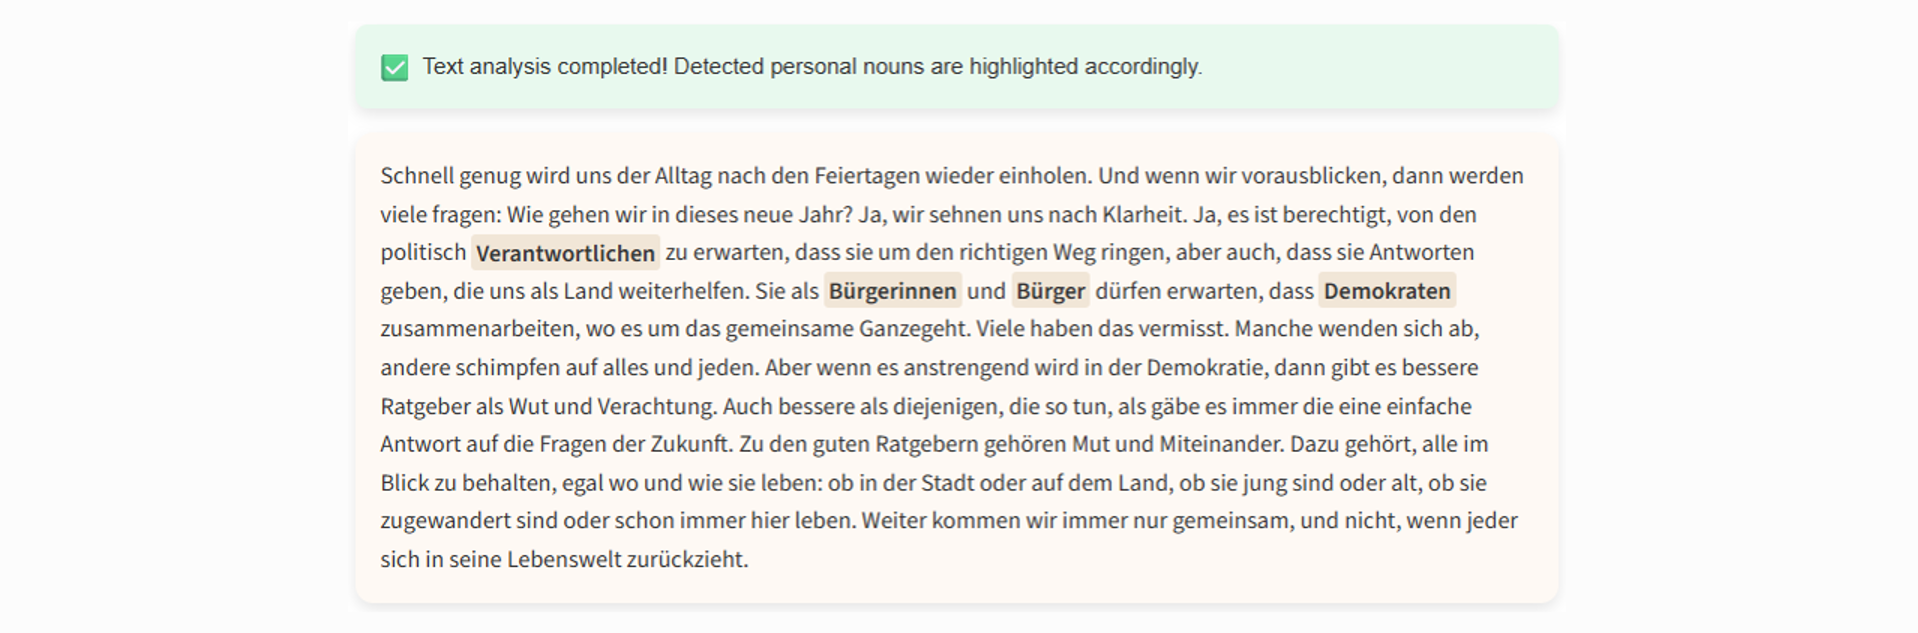
